<h1 align="center">Traffic Managament System Model</h1>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import pygeohash as pgh
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [4]:
print(df_train.info())
print(f"\nNull values : \n{df_train.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB
None

Null values : 
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather         

In [5]:
df_train['RoadType']  = df_train['RoadType'].fillna(df_train['RoadType'].mode()[0])
df_train['Weather']  = df_train['Weather'].fillna(df_train['Weather'].mode()[0])
df_train['Temperature']  = df_train['Temperature'].fillna(df_train['Temperature'].median())

In [6]:
df_test['RoadType']  = df_test['RoadType'].fillna(df_test['RoadType'].mode()[0])
df_test['Weather']  = df_test['Weather'].fillna(df_test['Weather'].mode()[0])
df_test['Temperature']  = df_test['Temperature'].fillna(df_test['Temperature'].median())

In [7]:
time_split = df_train['timestamp'].str.split(':', expand=True).astype(int)
df_train['hour'] = time_split[0]
df_train['minute'] = time_split[1]

In [8]:
time_split = df_test['timestamp'].str.split(':', expand=True).astype(int)
df_test['hour'] = time_split[0]
df_test['minute'] = time_split[1]

In [9]:
df_train_numeric = df_train[['day','demand','NumberofLanes','Temperature','hour','minute']]
df_train_cat = df_train[['RoadType','Weather','LargeVehicles','Landmarks']]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform="pandas")
df_train_cat = encoder.fit_transform(df_train_cat)

df_train_new = pd.concat([df_train_cat,df_train_numeric], axis=1)
df_train_new.head()

,RoadType_Highway,RoadType_Residential,RoadType_Street,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,LargeVehicles_Allowed,LargeVehicles_Not Allowed,Landmarks_No,Landmarks_Yes,day,demand,NumberofLanes,Temperature,hour,minute
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,48,0.048804,1,16.382587,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,48,0.118507,3,31.104565,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,48,0.027132,1,25.919267,0,0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,48,0.003272,1,16.382587,0,0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,48,0.010819,1,10.803667,0,0


In [10]:
#Preprocess Test Data
df_test_numeric = df_test[['day','NumberofLanes','Temperature','hour','minute']]
df_test_cat = df_test[['RoadType','Weather','LargeVehicles','Landmarks']]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform="pandas")
df_test_cat = encoder.fit_transform(df_test_cat)

df_test_new = pd.concat([df_test_cat,df_test_numeric], axis=1)
df_test_new.head()

,RoadType_Highway,RoadType_Residential,RoadType_Street,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,LargeVehicles_Allowed,LargeVehicles_Not Allowed,Landmarks_No,Landmarks_Yes,day,NumberofLanes,Temperature,hour,minute
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,49,1,16.471232,2,15
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,49,1,6.476213,2,15
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,49,3,22.318203,2,15
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,49,2,16.471232,2,15
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,49,1,18.266162,2,15


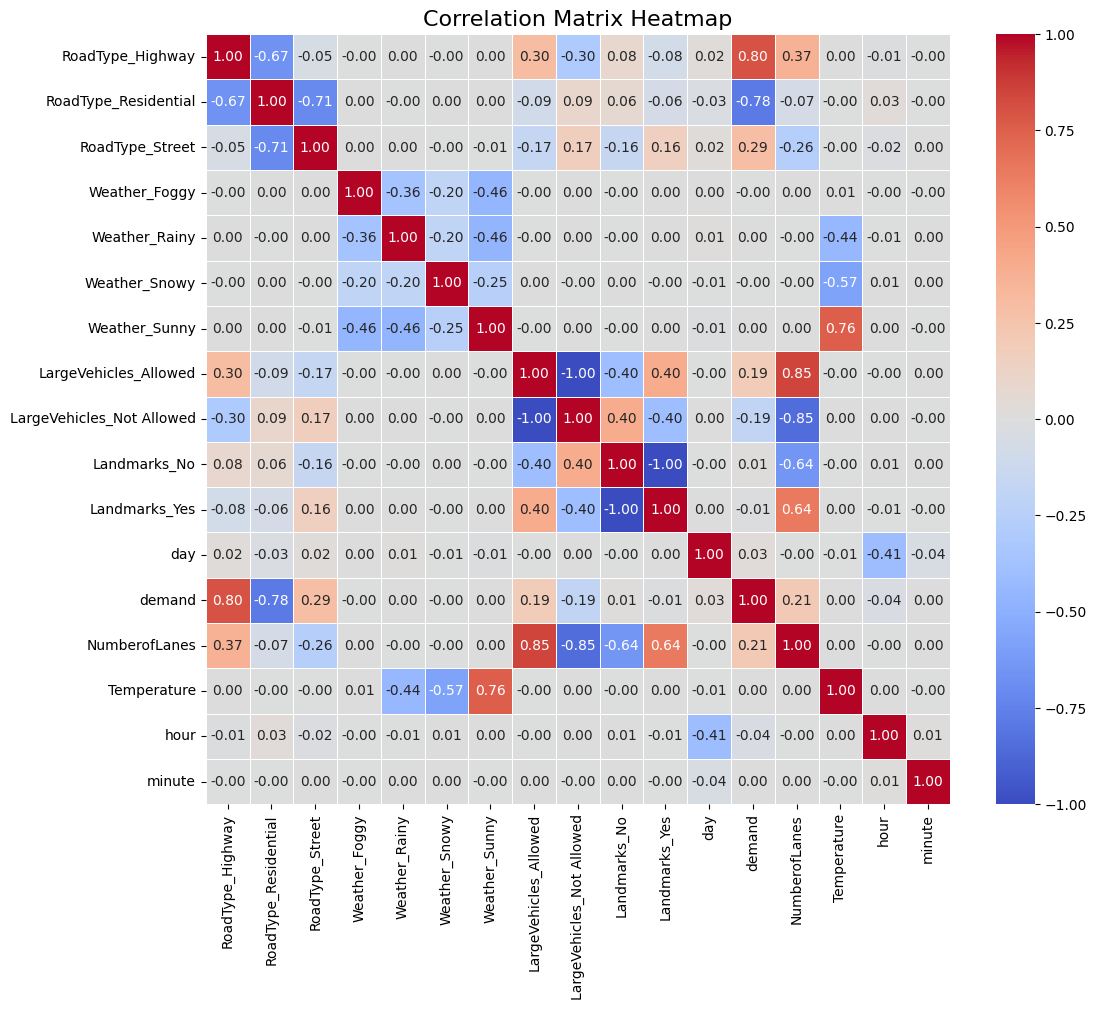

In [11]:
corr_matrix = df_train_new.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",     
    vmin=-1, vmax=1,    
    linewidths=0.5      
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.show()

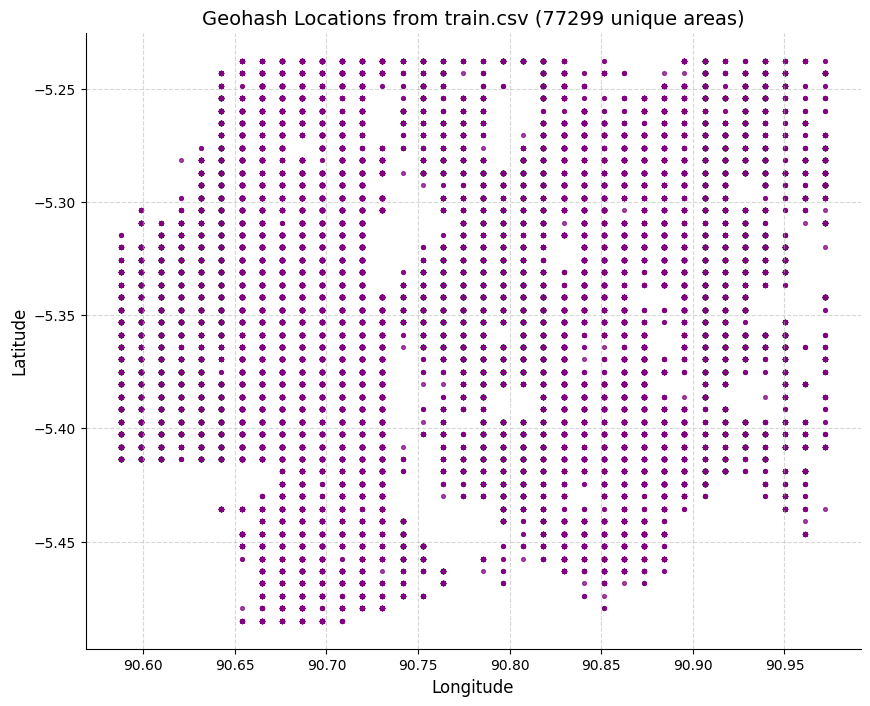

In [12]:
#Converting Geohash to coordinates
def decode_geohash(gh):
    try:
        return pgh.decode(gh)
    except Exception:
        # Handle invalid geohashes gracefully
        return (None, None)

df_train_new[['latitude', 'longitude']] = df_train['geohash'].apply(
    lambda x: pd.Series(decode_geohash(x))
)
df_test_new[['latitude', 'longitude']] = df_test['geohash'].apply(
    lambda x: pd.Series(decode_geohash(x))
)


plt.figure(figsize=(10, 8))
plt.scatter(
    df_train_new['longitude'], 
    df_train_new['latitude'], 
    color='purple', 
    marker='.', 
    s=30, 
    alpha=0.7
)

# Plot formatting
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title(f'Geohash Locations from train.csv ({len(df_train_new)} unique areas)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Clean up visual borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

In [13]:
#As we have two days only I have binary classified day column
df_train_new['day_binary'] = (df_train_new['day'] == 49).astype(int)
df_train_new= df_train_new.drop(columns=['day'])

#converts 14:30 or Hour =14 and minute =30 into 14.5 helps in mathematical calculations
#time_sin and time_cos are used so that model does not think that 23.9 and 0.6 time are far apart but just 12 minutes apart
fractional_hour = df_train_new['hour'] + (df_train_new['minute'] / 60.0)
df_train_new['time_sin'] = np.sin(2 * np.pi * fractional_hour / 24.0)
df_train_new['time_cos'] = np.cos(2 * np.pi * fractional_hour / 24.0)

#Normalization of Temperature,NumberOfLanes,latitude and longitude and demand columns
scaler = StandardScaler()
cols_to_scale = ['Temperature', 'latitude', 'longitude']
df_train_new[cols_to_scale] = scaler.fit_transform(df_train_new[cols_to_scale])

df_train_new.head()

,RoadType_Highway,RoadType_Residential,RoadType_Street,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,LargeVehicles_Allowed,LargeVehicles_Not Allowed,Landmarks_No,...,demand,NumberofLanes,Temperature,hour,minute,latitude,longitude,day_binary,time_sin,time_cos
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.048804,1,-0.003043,0,0,-2.367230,-0.964529,0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.118507,3,2.030369,0,0,-1.986337,-0.751393,0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.027132,1,1.314171,0,0,-1.986337,-0.538257,0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.003272,1,-0.003043,0,0,-1.986337,0.953696,0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.010819,1,-0.773608,0,0,-1.891114,-0.857961,0,0.0,1.0


In [14]:
#As we have two days only I have binary classified day column
df_test_new['day_binary'] = (df_test_new['day'] == 49).astype(int)
df_test_new= df_test_new.drop(columns=['day'])

#converts 14:30 or Hour =14 and minute =30 into 14.5 helps in mathematical calculations
#time_sin and time_cos are used so that model does not think that 23.9 and 0.6 time are far apart but just 12 minutes apart
fractional_hour = df_test_new['hour'] + (df_test_new['minute'] / 60.0)
df_test_new['time_sin'] = np.sin(2 * np.pi * fractional_hour / 24.0)
df_test_new['time_cos'] = np.cos(2 * np.pi * fractional_hour / 24.0)

#Normalization of Temperature,NumberOfLanes,latitude and longitude and demand columns
scaler = StandardScaler()
cols_to_scale = ['Temperature', 'latitude', 'longitude']
df_test_new[cols_to_scale] = scaler.fit_transform(df_test_new[cols_to_scale])

df_test_new.head()

,RoadType_Highway,RoadType_Residential,RoadType_Street,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,LargeVehicles_Allowed,LargeVehicles_Not Allowed,Landmarks_No,Landmarks_Yes,NumberofLanes,Temperature,hour,minute,latitude,longitude,day_binary,time_sin,time_cos
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,0.001859,2,15,-2.243500,-1.013201,1,0.55557,0.83147
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1,-1.380325,2,15,-2.243500,-0.798455,1,0.55557,0.83147
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3,0.810421,2,15,-2.151963,-1.120574,1,0.55557,0.83147
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,2,0.001859,2,15,-2.151963,-0.905828,1,0.55557,0.83147
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1,0.250075,2,15,-2.151963,-0.798455,1,0.55557,0.83147


In [16]:
x = df_train_new.drop(['demand','hour','minute'], axis=1)
y = df_train_new['demand']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

decisionTree = DecisionTreeRegressor(max_depth=50,splitter="best",random_state=42)
decisionTree.fit(x_train,y_train)
y_pred = decisionTree.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
score = max(0,100*r2)
print(f"Mean Squared Error : {(mse*100):.4f}%")
print(f"R2 Score : {(r2*100):.4f}")
print(f"Score (Competition) : {(score):.4f}%")

Mean Squared Error : 0.1933%
R2 Score : 90.4487
Score (Competition) : 90.4487%


In [17]:
randomForest = RandomForestRegressor(n_estimators=200,max_depth=50,random_state=42)
randomForest.fit(x_train,y_train)
y_pred = randomForest.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
score = max(0,100*r2)
print(f"Mean Squared Error : {(mse*100):.4f}%")
print(f"R2 Score : {(r2*100):.4f}")
print(f"Score (Competition) : {(score):.4f}%")

Mean Squared Error : 0.1138%
R2 Score : 94.3771
Score (Competition) : 94.3771%


In [18]:
model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=10)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
score = max(0,100*r2)
print(f"Mean Squared Error : {(mse*100):.4f}%")
print(f"R2 Score : {(r2*100):.4f}")
print(f"Score (Competition) : {(score):.4f}%")

Mean Squared Error : 0.1465%
R2 Score : 92.7575
Score (Competition) : 92.7575%


In [19]:
x_final = df_test_new.drop(['hour','minute'], axis=1)
y_final = randomForest.predict(x_final)
if 'Index' in df_test_new.columns:
    indices = df_test_new['Index']
else:
    # Assuming test data had 'Index' from 0 to len(y_final)-1
    indices = range(len(y_final))

submission = pd.DataFrame({
    'Index': indices,
    'demand': y_final
})

# Save to CSV
submission.to_csv('prediction.csv', index=False)
print("Saved prediction.csv successfully!")
submission.head()

Saved prediction.csv successfully!


,Index,demand
0,0,0.053262
1,1,0.056047
2,2,0.044792
3,3,0.038127
4,4,0.090344
